In [7]:
import os, cv2, numpy as np, random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
SEED = 15
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

In [10]:
REAL_DIR = "/content/drive/My Drive/Research Project/ffhq_7k/train"
FAKE_DIR = "/content/drive/My Drive/Research Project/StyleGAN2_7k/train"
IMG_SIZE = (128, 128)

In [11]:
def load_spatial(real_dir, fake_dir, img_size=(128, 128), limit=None):
    X, y = [], []
    def proc(p):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32)/255.0
        return img[..., None]
    reals = sorted(os.listdir(real_dir))
    fakes = sorted(os.listdir(fake_dir))
    if limit: reals, fakes = reals[:limit], fakes[:limit]
    for fn in reals:
        X.append(proc(os.path.join(real_dir, fn))); y.append(0)
    for fn in fakes:
        X.append(proc(os.path.join(fake_dir, fn))); y.append(1)
    return np.array(X), np.array(y)


In [12]:
X, y = load_spatial(REAL_DIR, FAKE_DIR)
print("Spatial shape:", X.shape, "labels:", y.shape)

Spatial shape: (10575, 128, 128, 1) labels: (10575,)


In [13]:
def build_branch(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, (4,4), activation='relu')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, out)

In [14]:
model = build_branch((128,128,1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
early_stop = EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True)
history = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=20, batch_size=35, callbacks=[early_stop], verbose=1)
print("Test eval:", model.evaluate(Xte, yte, verbose=0))

Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 131s 528ms/step - accuracy: 0.6365 - loss: 0.6157 - val_accuracy: 0.7943 - val_loss: 0.4432
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 143s 533ms/step - accuracy: 0.7849 - loss: 0.4590 - val_accuracy: 0.8217 - val_loss: 0.4016
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 136s 508ms/step - accuracy: 0.8299 - loss: 0.3851 - val_accuracy: 0.8544 - val_loss: 0.3418
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 125s 517ms/step - accuracy: 0.8486 - loss: 0.3436 - val_accuracy: 0.8695 - val_loss: 0.3191
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 141s 513ms/step - accuracy: 0.8727 - loss: 0.2955 - val_accuracy: 0.8761 - val_loss: 0.2893
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 138s 496ms/step - accuracy: 0.8750 - loss: 0.2807 - val_accuracy: 0.8870 - val_loss: 0.2987
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 142s 498ms/step - accuracy: 0.9038 - loss: 0.2313 - val_accuracy: 0.8837 - val_loss: 0.2814
Epoch 8/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 141s 495ms/step - accuracy: 0.9072 -

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
StyleGAN3 Test Shapes: (3525, 128, 128, 1) (3525,)
111/111 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.7315 - loss: 1.6280
StyleGAN3 Test Loss: 4.420423984527588
StyleGAN3 Test Accuracy: 0.4541843831539154
111/111 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step

Classification Report (StyleGAN3 Test Set):
              precision    recall  f1-score   support

        Real       0.47      0.84      0.60      1750
        Fake       0.30      0.07      0.11      1775

    accuracy                           0.45      3525
   macro avg       0.38      0.45      0.36      3525
weighted avg       0.38      0.45      0.35      3525



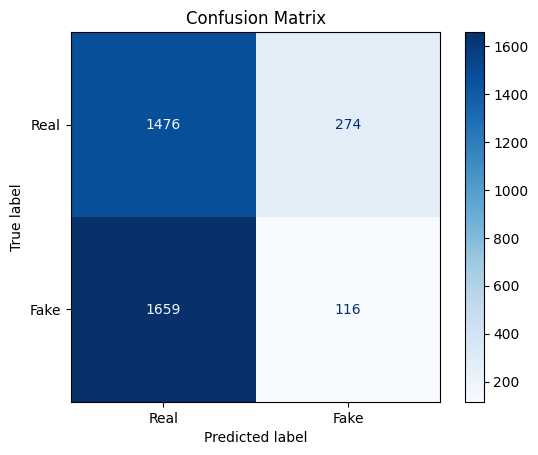

Number of misclassified images: 1933


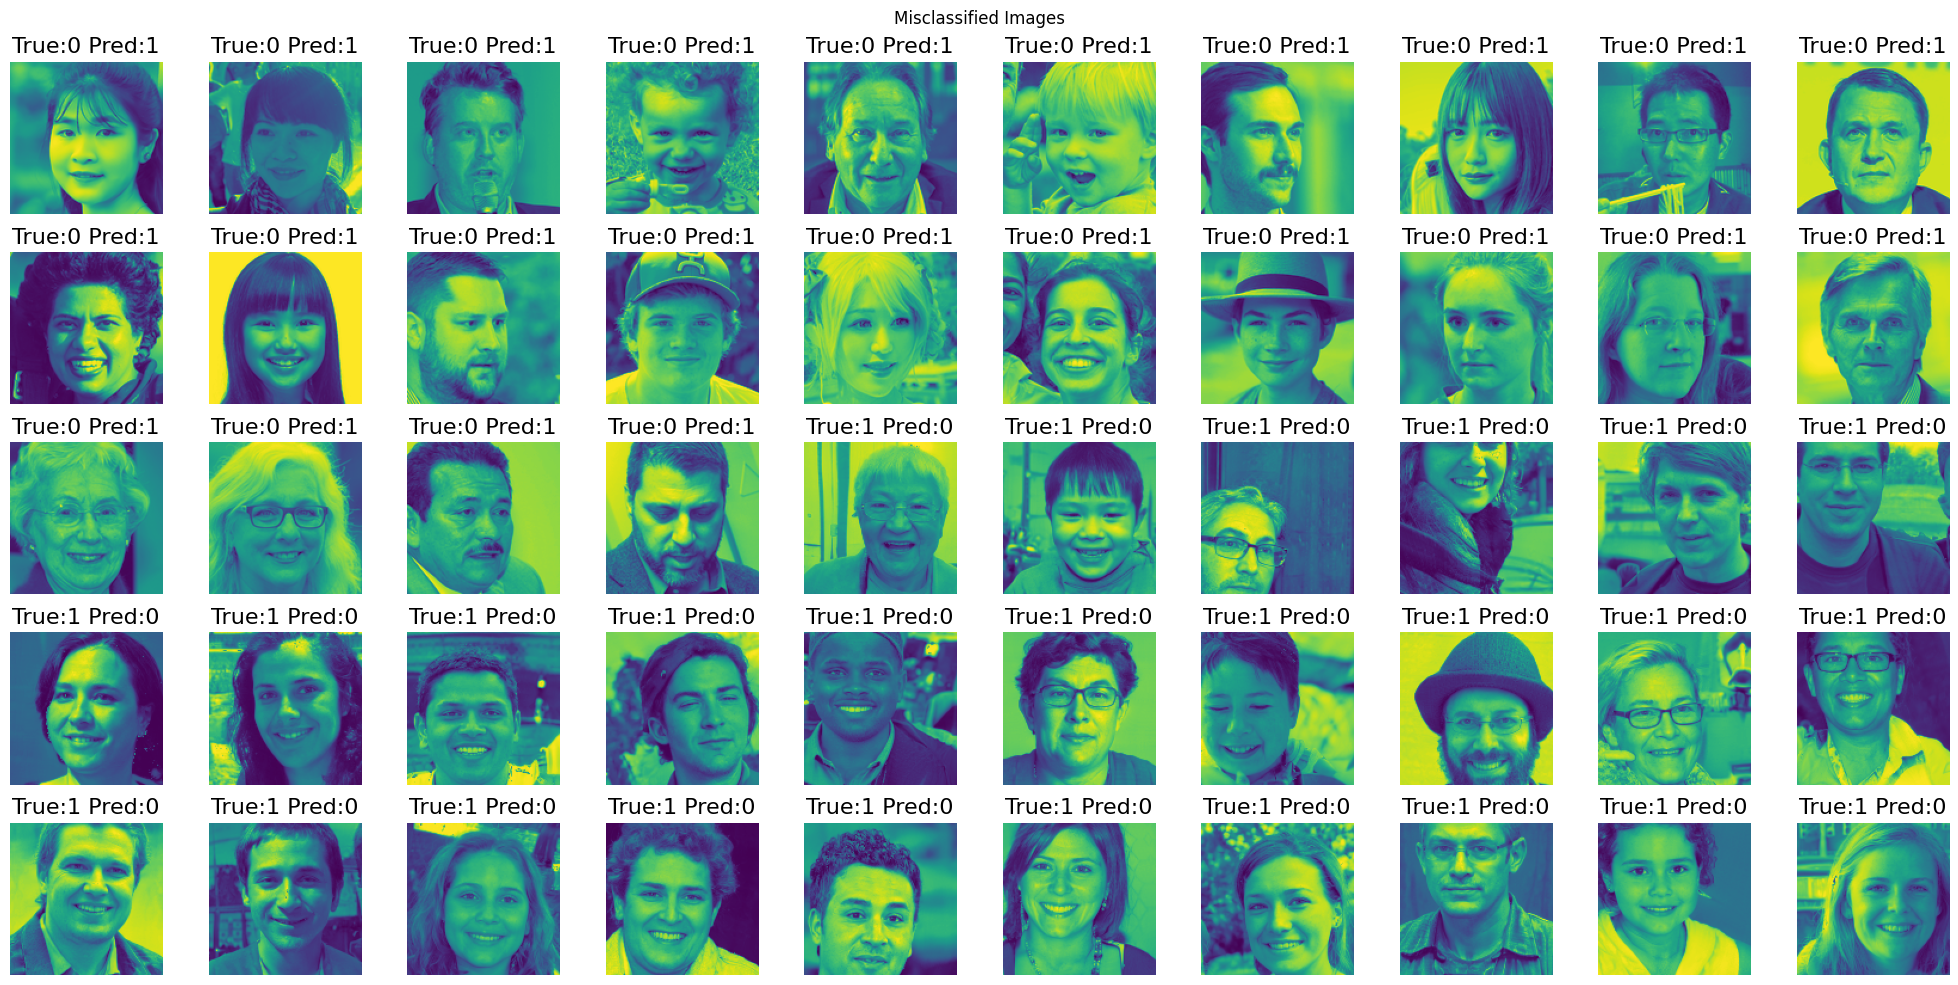

In [17]:
from sklearn.metrics import accuracy_score, classification_report

from google.colab import drive
drive.mount('/content/drive')

REAL_TEST_DIR = "/content/drive/My Drive/Research Project/ffhq_7k/test"
FAKE_TEST_DIR = "/content/drive/My Drive/Research Project/StyleGAN3_7k/test"

X_test,  y_test = load_spatial(REAL_TEST_DIR, FAKE_TEST_DIR, img_size=IMG_SIZE, limit=None)

print("StyleGAN3 Test Shapes:", X_test.shape, y_test.shape)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("StyleGAN3 Test Loss:", test_loss)
print("StyleGAN3 Test Accuracy:", test_acc)


y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.4).astype("int32").flatten()

print("\nClassification Report (StyleGAN3 Test Set):")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()


misclassified_idx = np.where(y_pred != y_test)[0]
print("Number of misclassified images:", len(misclassified_idx))

n_show = 50
row=5
cols=10

plt.figure(figsize=(20, 10))
for i, idx in enumerate(misclassified_idx[250:300]):
    plt.subplot(row, cols, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True:{y_test[idx]} Pred:{y_pred[idx]}",fontsize=16)
    plt.axis("off")
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()